In [42]:
import pandas as pd
import os
import cv2
import random
from pandas import read_excel
from pandas import DataFrame
from sklearn.decomposition import PCA
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import pickle
import matplotlib.pyplot as plt
from functions import *

Train data

In [2]:
file_name = 'data_train_augm_Pb.xlsx'
df = read_excel(file_name, sheet_name = 'Relavage Pb')

In [3]:
df

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl1_pb2-4-0.jpg,1.245513,6.959282,13.938595,3.244900
1,rl1_pb2-4-1.jpg,1.967959,7.476666,13.957256,3.316974
2,rl1_pb2-4-10.jpg,1.738068,8.358878,13.832301,2.216290
3,rl1_pb2-4-11.jpg,1.695532,8.051285,13.553668,1.922395
4,rl1_pb2-4-12.jpg,0.609515,8.413778,13.492315,2.881374
...,...,...,...,...,...
1553,rl4_pb8-7-59.jpg,0.594924,10.860318,50.687493,3.865887
1554,rl4_pb8-7-6.jpg,1.625748,9.903235,50.588142,4.437520
1555,rl4_pb8-7-7.jpg,0.798550,10.961176,50.785080,4.004402
1556,rl4_pb8-7-8.jpg,0.903597,10.362348,50.590920,5.283421


In [4]:
fft_features = []
labels_cu = []
labels_pb = []
labels_fe = []
labels_zn = []

In [5]:
for line in df.values:
    image = cv2.imread("../train_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    fft_features.append(fft_pca)
    labels_cu.append(line[1])
    labels_fe.append(line[2])
    labels_pb.append(line[3])
    labels_zn.append(line[4])

In [6]:
fft_features = np.array(fft_features)
labels_cu = np.array(labels_cu)
labels_fe = np.array(labels_fe)
labels_pb = np.array(labels_pb)
labels_zn = np.array(labels_zn)

In [7]:
fft_features.shape

(1558, 800)

In [8]:
labels_cu.shape, labels_fe.shape, labels_pb.shape, labels_zn.shape

((1558,), (1558,), (1558,), (1558,))

In [9]:
labels = np.array([labels_cu, labels_fe, labels_pb, labels_zn]).T

In [10]:
labels.shape

(1558, 4)

SVM with FFT and PCA

In [11]:
svm = SVR()
msvm = MultiOutputRegressor(svm)
msvm.fit(fft_features, labels)

MultiOutputRegressor(estimator=SVR())

Linear Regression with FFT and PCA

In [12]:
lr = LinearRegression()
mlr = MultiOutputRegressor(lr)
mlr.fit(fft_features, labels)

MultiOutputRegressor(estimator=LinearRegression())

XGBoost with FFT and PCA

In [13]:
xgb = XGBRegressor()
mxgb = MultiOutputRegressor(xgb)
mxgb.fit(fft_features, labels)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            gpu_id=None, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            predictor=None, random_state=None, ...))

Catboost with FFT and PCA

In [14]:
cbr = cb.CatBoostRegressor()
mcb = MultiOutputRegressor(cbr)
mcb.fit(fft_features, labels, verbose=False)

MultiOutputRegressor(estimator=<catboost.core.CatBoostRegressor object at 0x000002A06E48ABB0>)

Random Forest with FFT and PCA

In [15]:
rf = RandomForestRegressor()
mrf = MultiOutputRegressor(rf)
mrf.fit(fft_features, labels)

MultiOutputRegressor(estimator=RandomForestRegressor())

Gradient Boosting with FFT and PCA

In [43]:
gb = GradientBoostingRegressor()
mgb = MultiOutputRegressor(gb)
mgb.fit(fft_features, labels)

MultiOutputRegressor(estimator=GradientBoostingRegressor())

Ada Boost with FFT and PCA

In [44]:
ada = AdaBoostRegressor()
mada = MultiOutputRegressor(ada)
mada.fit(fft_features, labels)

MultiOutputRegressor(estimator=AdaBoostRegressor())

Decision Trees with FFT and PCA

In [45]:
dt = DecisionTreeRegressor()
mdt = MultiOutputRegressor(dt)
mdt.fit(fft_features, labels)

MultiOutputRegressor(estimator=DecisionTreeRegressor())

KNN with FFT and PCA

In [46]:
knn = KNeighborsRegressor()
mknn = MultiOutputRegressor(knn)
mknn.fit(fft_features, labels)

MultiOutputRegressor(estimator=KNeighborsRegressor())

test data

In [16]:
test_file_name = 'data_test_augm_Pb.xlsx'
df_test = read_excel(test_file_name, sheet_name = 'Relavage Pb')

In [17]:
df_test

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl3_pb2-4-0.jpg,0.955567,4.364904,24.561805,1.555980
1,rl3_pb2-4-1.jpg,0.808028,5.158964,24.657665,2.548098
2,rl3_pb2-4-10.jpg,0.492004,5.501898,24.477975,1.090313
3,rl3_pb2-4-11.jpg,1.156483,5.456591,24.835752,2.335296
4,rl3_pb2-4-12.jpg,0.308988,4.538735,24.801103,1.234859
...,...,...,...,...,...
385,rl4_pb30-6-60.jpg,3.500198,6.684917,57.855643,1.833810
386,rl4_pb30-6-61.jpg,2.120330,5.953919,58.267221,1.779774
387,rl4_pb30-6-7.jpg,2.030106,6.826773,58.219045,2.553725
388,rl4_pb30-6-8.jpg,3.378046,6.280316,57.998101,2.442782


In [18]:
test_fft_features = []
test_labels_cu = []
test_labels_fe = []
test_labels_pb = []
test_labels_zn = []

In [19]:
for line in df_test.values:
    image = cv2.imread("../test_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    test_fft_features.append(fft_pca)
    test_labels_cu.append(line[1])
    test_labels_fe.append(line[2])
    test_labels_pb.append(line[3])
    test_labels_zn.append(line[4])

In [20]:
test_fft_features = np.array(test_fft_features)
test_labels_cu = np.array(test_labels_cu)
test_labels_fe = np.array(test_labels_fe)
test_labels_pb = np.array(test_labels_pb)
test_labels_zn = np.array(test_labels_zn)

In [21]:
test_fft_features.shape

(390, 800)

In [22]:
test_labels_cu.shape, test_labels_fe.shape, test_labels_pb.shape, test_labels_zn.shape

((390,), (390,), (390,), (390,))

In [23]:
test_labels = np.array([test_labels_cu, test_labels_fe, test_labels_pb, test_labels_zn]).T

In [24]:
test_labels.shape

(390, 4)

SVM

In [25]:
y_pred = msvm.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 5.281657203429354
MSE 62.93031860060888
R2 Score 0.07540354697502982


In [26]:
pickle.dump(msvm, open("./models/svm_model", 'wb'))

XGBoost

In [27]:
y_pred = mxgb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.197753459059576
MSE 44.63129495377938
R2 Score 0.20881251687036315


In [28]:
pickle.dump(mxgb, open("./models/xgboost_model", 'wb'))

Linear Regression

In [29]:
y_pred = mlr.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 5.167116571140998
MSE 75.00002968738579
R2 Score -0.09916302814256514


In [30]:
pickle.dump(mlr, open("./models/linear_regression_model", 'wb'))

Catboost

In [31]:
y_pred = mcb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.079751936784746
MSE 39.22855760359006
R2 Score 0.24973994328910237


In [32]:
pickle.dump(mcb, open("./models/catboost_model", 'wb'))

Random Forest

In [33]:
y_pred = mrf.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.111926208841917
MSE 38.949877880469884
R2 Score 0.2422689766127635


In [34]:
pickle.dump(mrf, open("./models/random_forest_model", 'wb'))

Grandient Boosting

In [47]:
y_pred = mgb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.188867662339286
MSE 42.00155149569851
R2 Score 0.24227715986399556


In [48]:
pickle.dump(mgb, open("./models/gradient_boosting_model", 'wb'))

Ada Boosting

In [49]:
y_pred = mada.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.3474644392636845
MSE 40.95137965598698
R2 Score 0.22361426623435318


In [50]:
pickle.dump(mada, open("./models/ada_boosting_model", 'wb'))

Decision Trees

In [51]:
y_pred = mdt.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 5.273670315091726
MSE 84.16241410731932
R2 Score -0.2714534190370043


In [52]:
pickle.dump(mdt, open("./models/decision_tree_model", 'wb'))

KNN

In [53]:
y_pred = mknn.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.1297085151441095
MSE 43.694481132936666
R2 Score 0.19761551993225968


In [54]:
pickle.dump(mknn, open("./models/knn_model", 'wb'))

In [35]:
TeunneurReel = TenneurReel("rl4_pb30-6.mp4", "DataSource.xlsx")

SVM

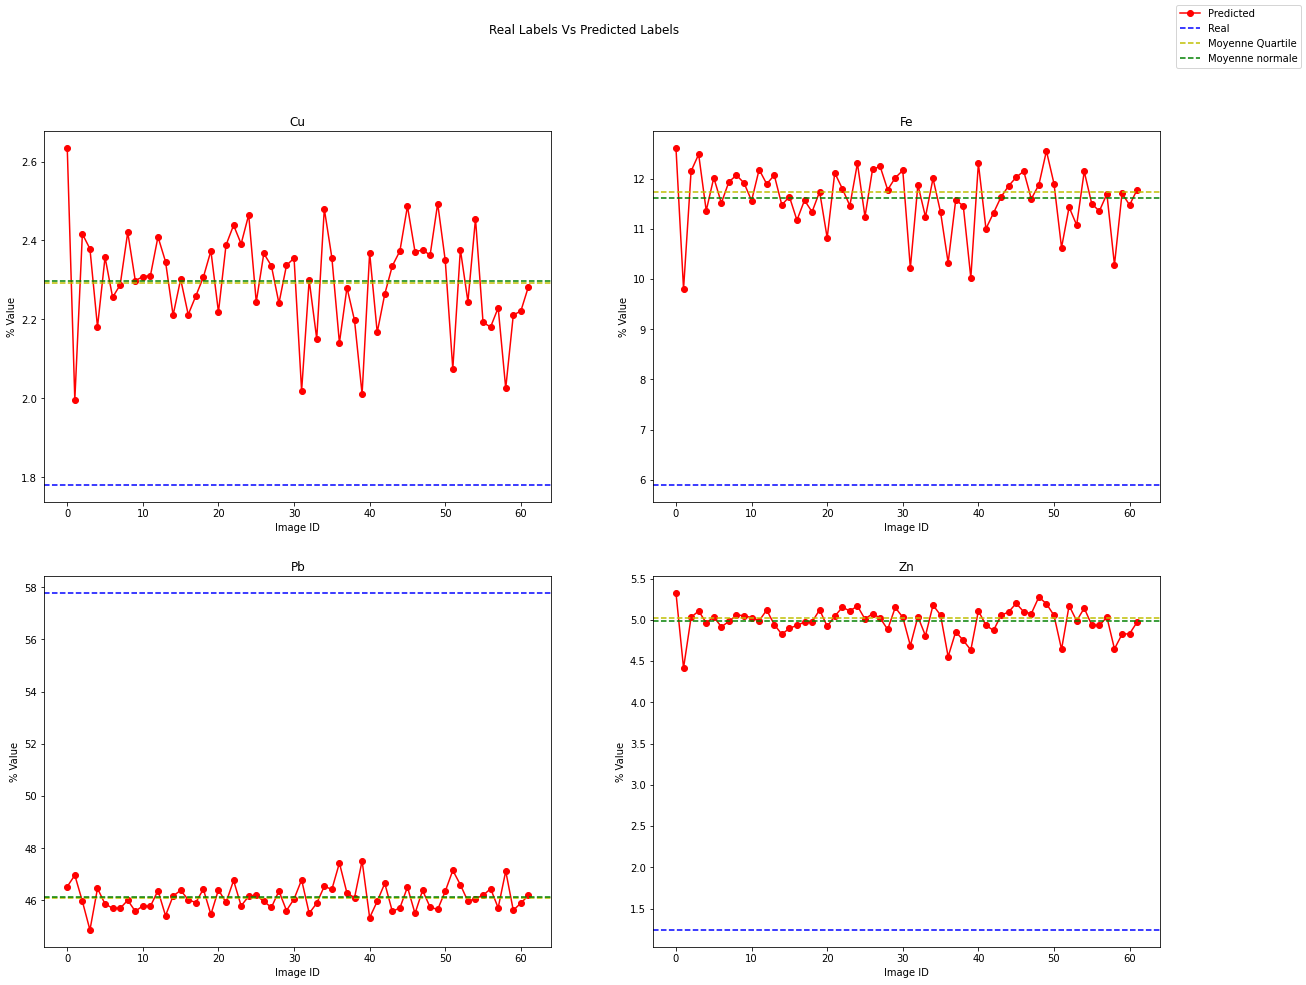

In [38]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", msvm)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Random Forest

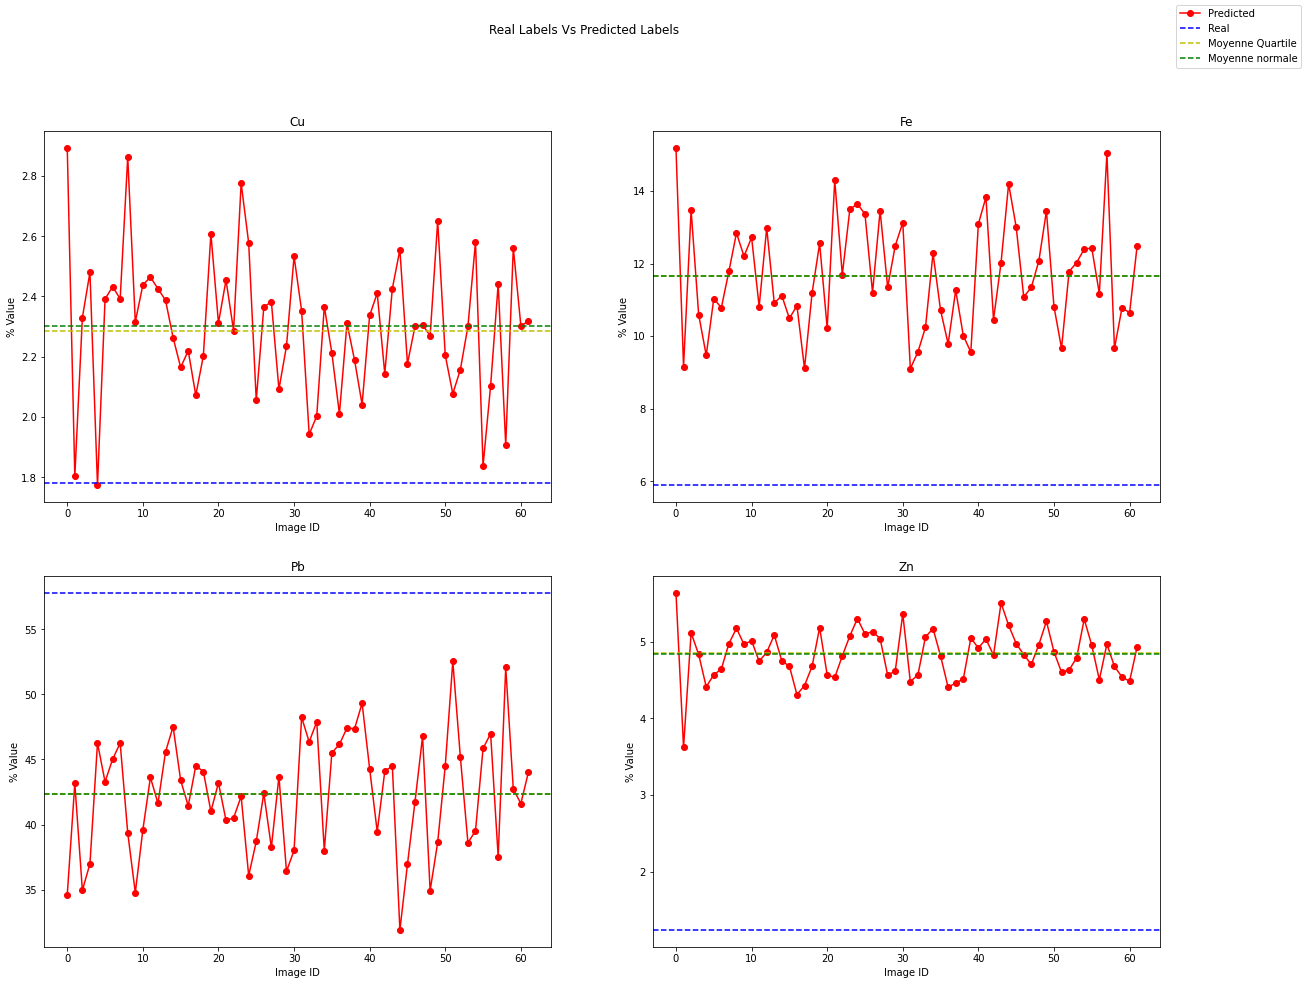

In [39]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", mrf)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

XGBoost

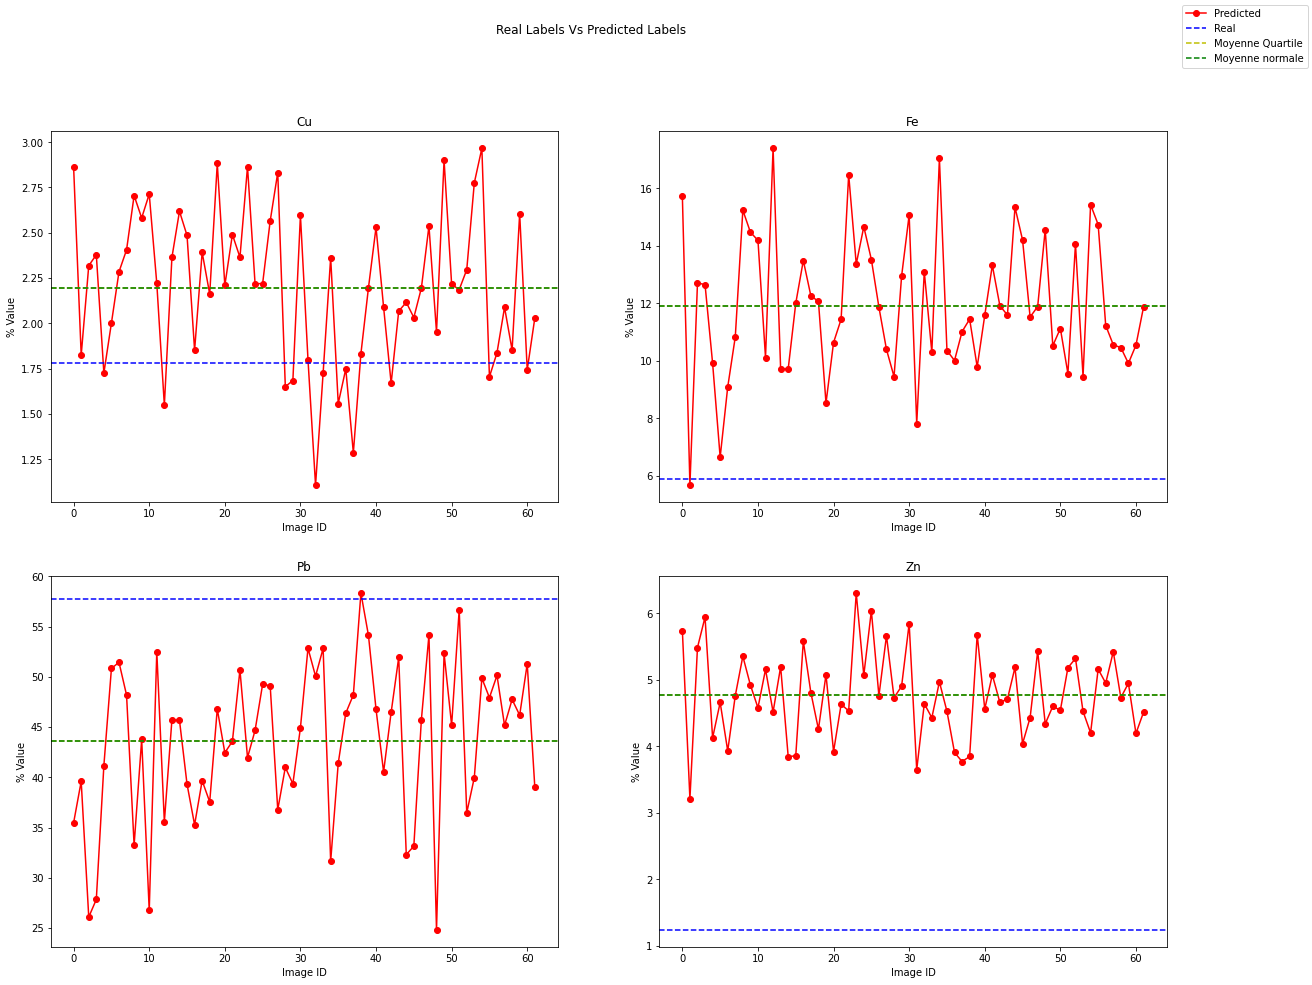

In [40]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", mxgb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Catboost

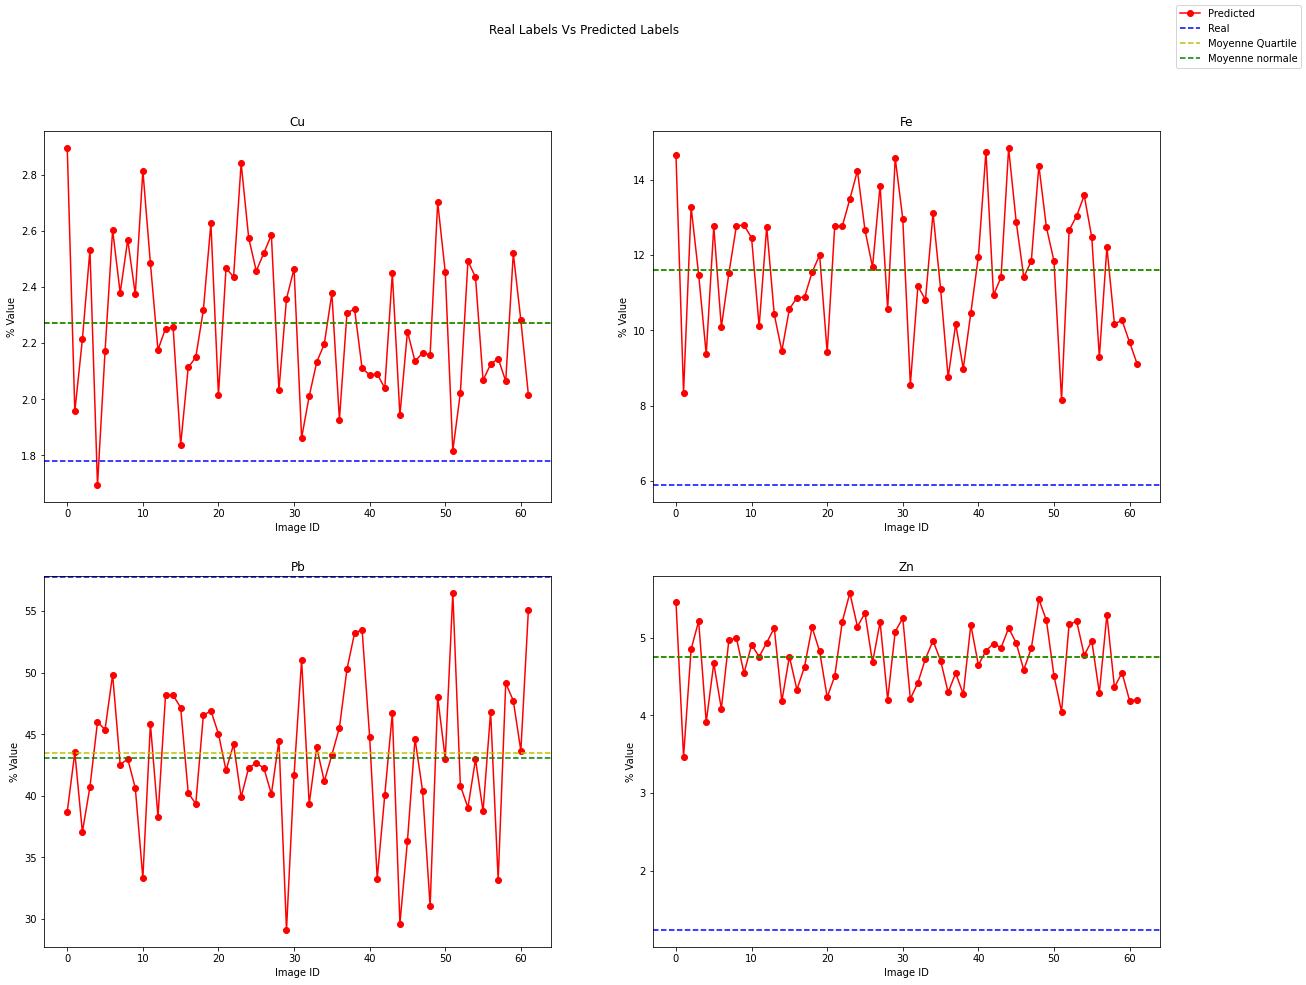

In [41]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", mcb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [42]:
TeunneurReel = TenneurReel("rl4_pb12-4.mp4", "DataSource.xlsx")

SVM

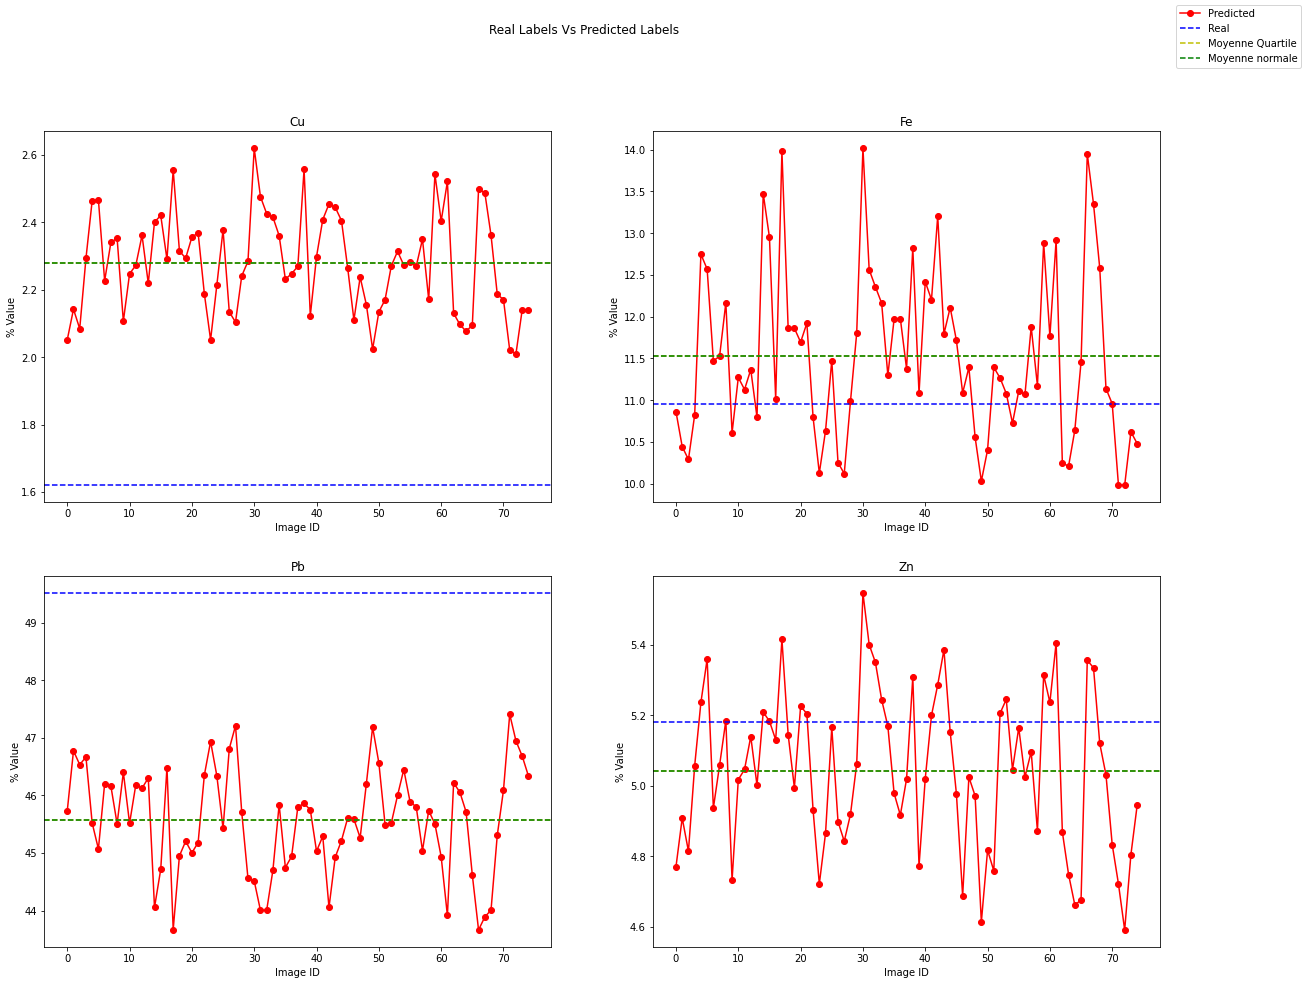

In [43]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", msvm)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Random Forest

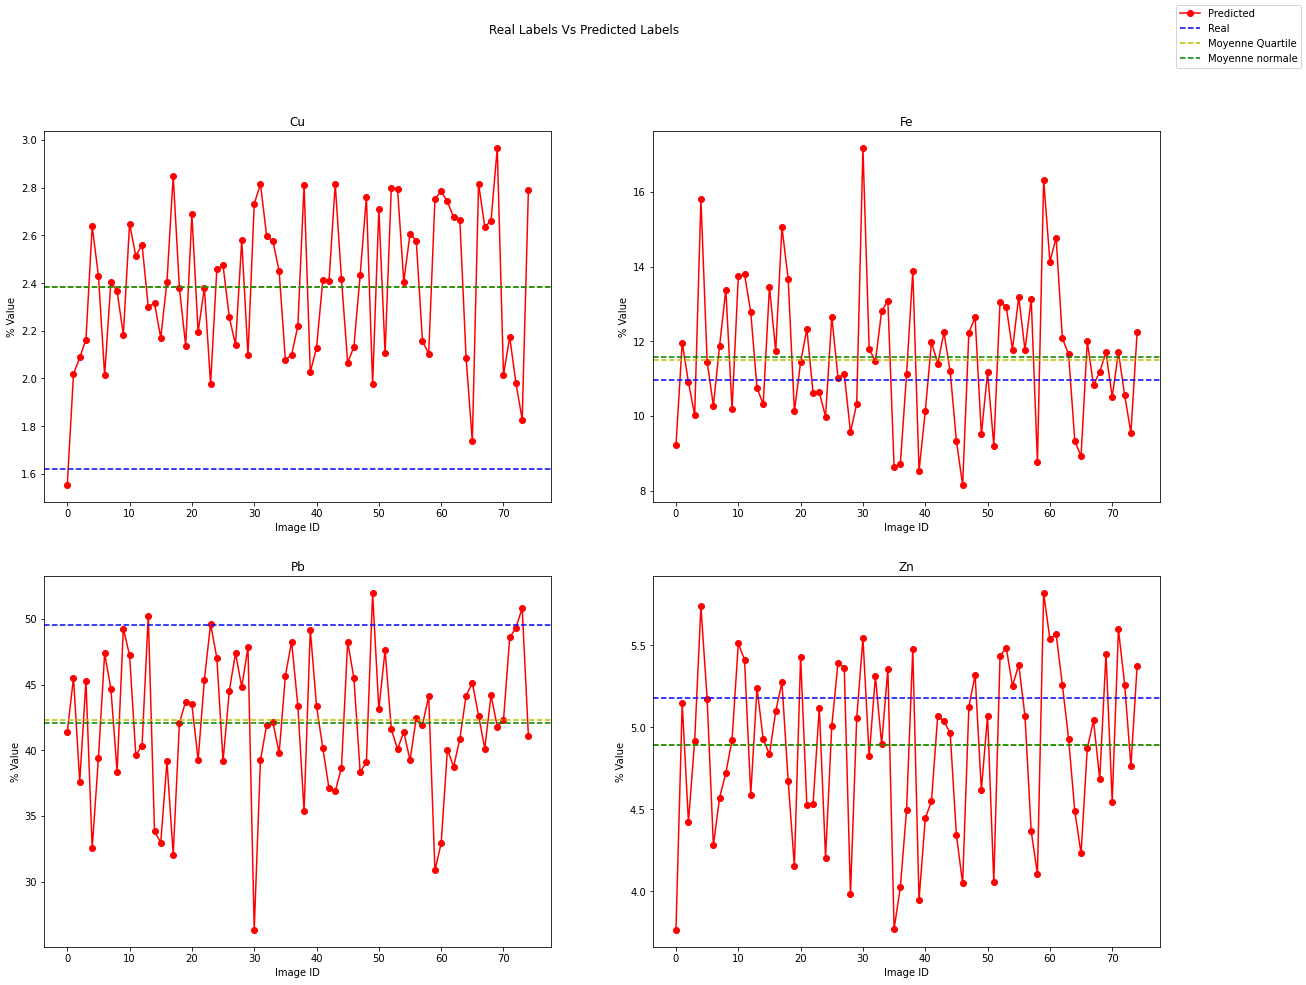

In [44]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", mrf)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

XGBoost

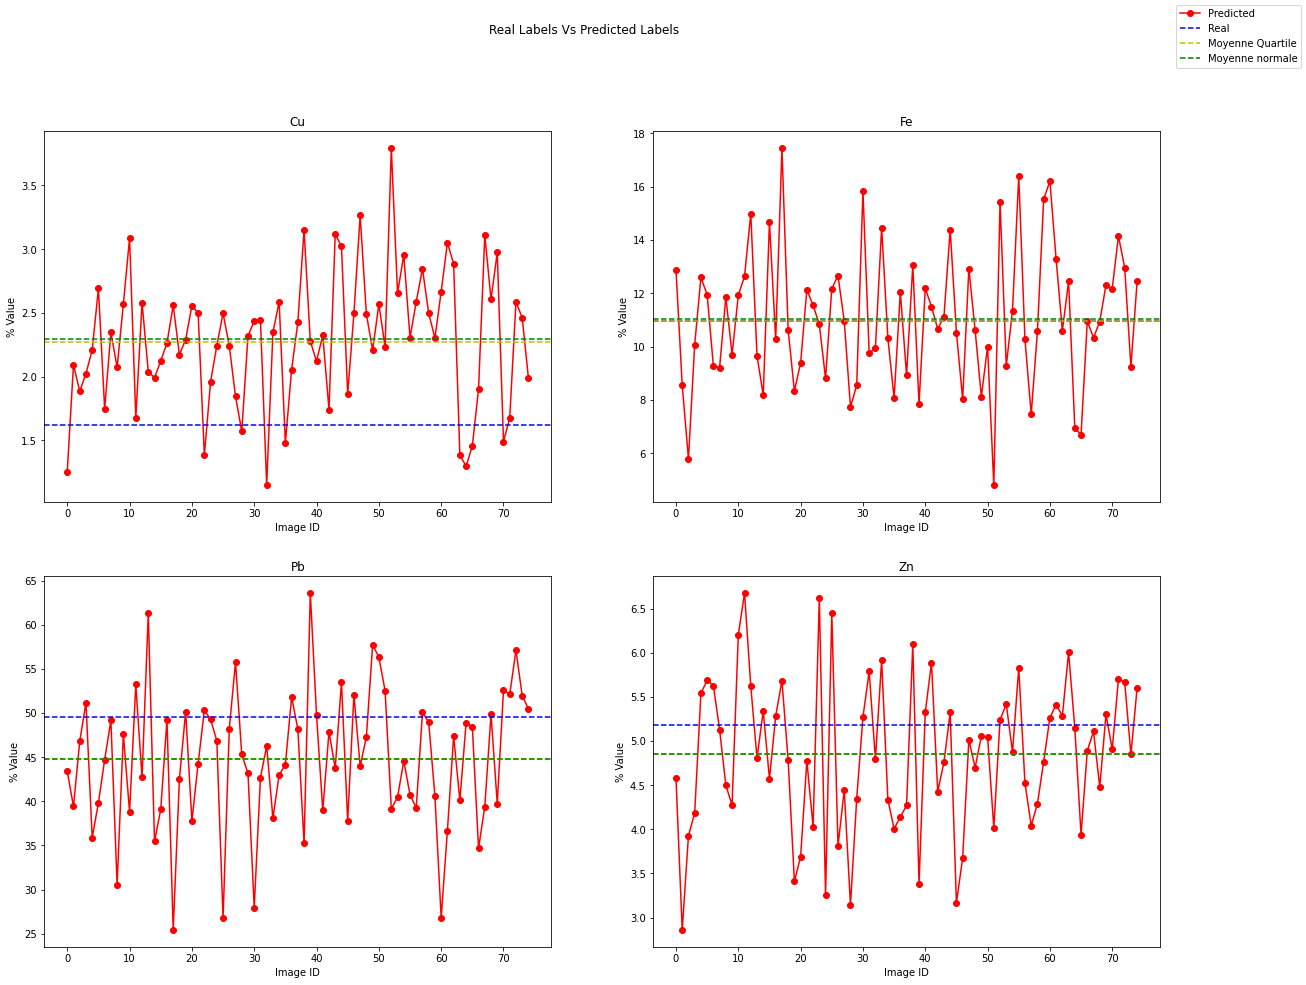

In [45]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", mxgb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Catboost

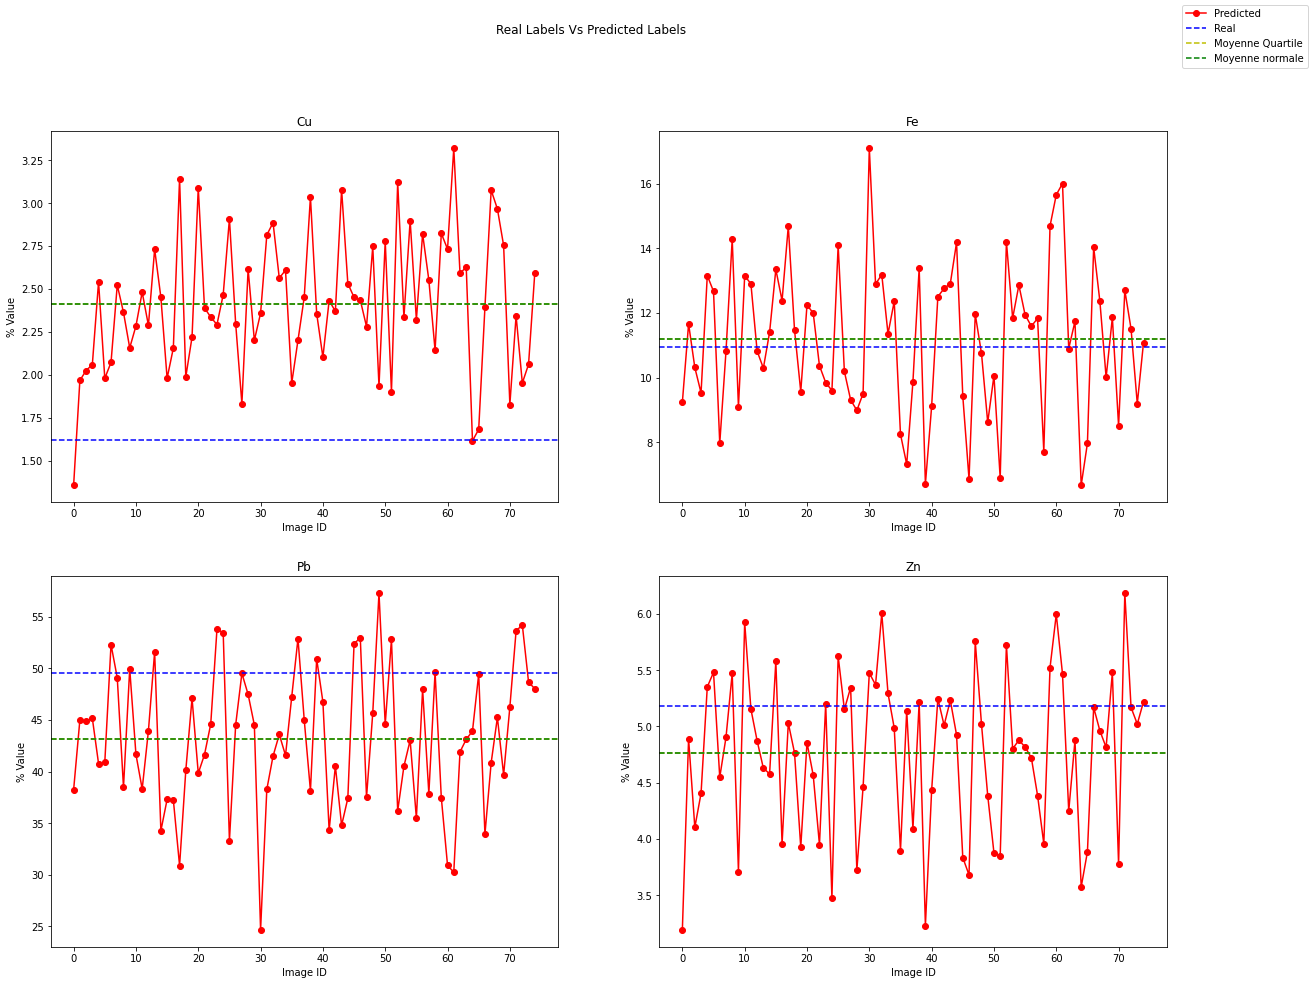

In [46]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", mcb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [47]:
msvm = pickle.load(open("./models/svm_model", 'rb'))
mxgb = pickle.load(open("./models/xgboost_model", 'rb'))
mcb = pickle.load(open("./models/catboost_model", 'rb'))
mrf = pickle.load(open("./models/random_forest_model", 'rb'))

In [48]:
TeunneurReel = TenneurReel("rl4_pb15-7.mp4", "DataSource.xlsx")

SVM

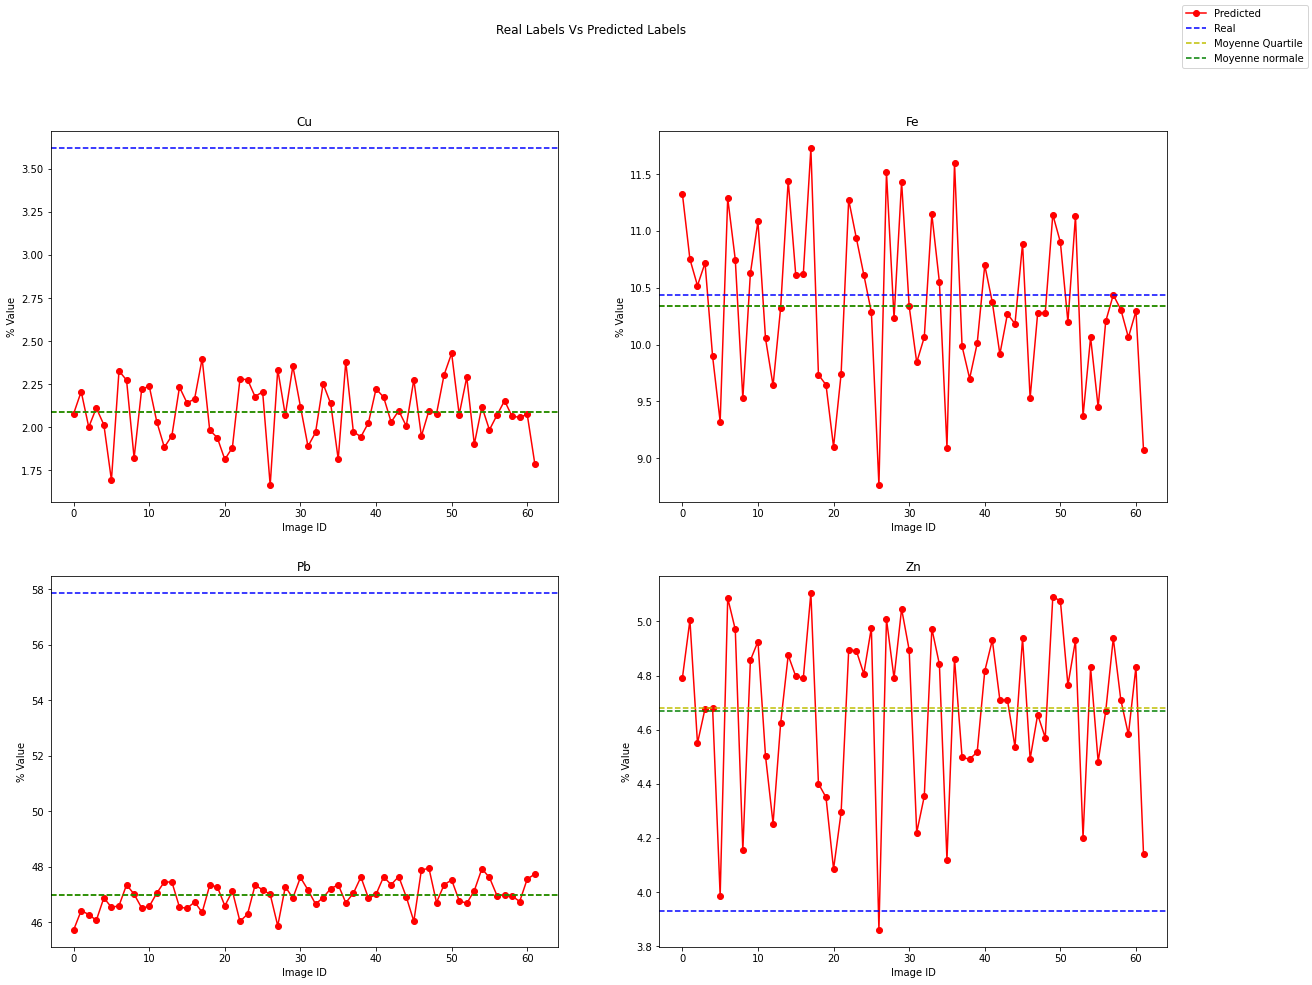

In [49]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", msvm)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Random Forest

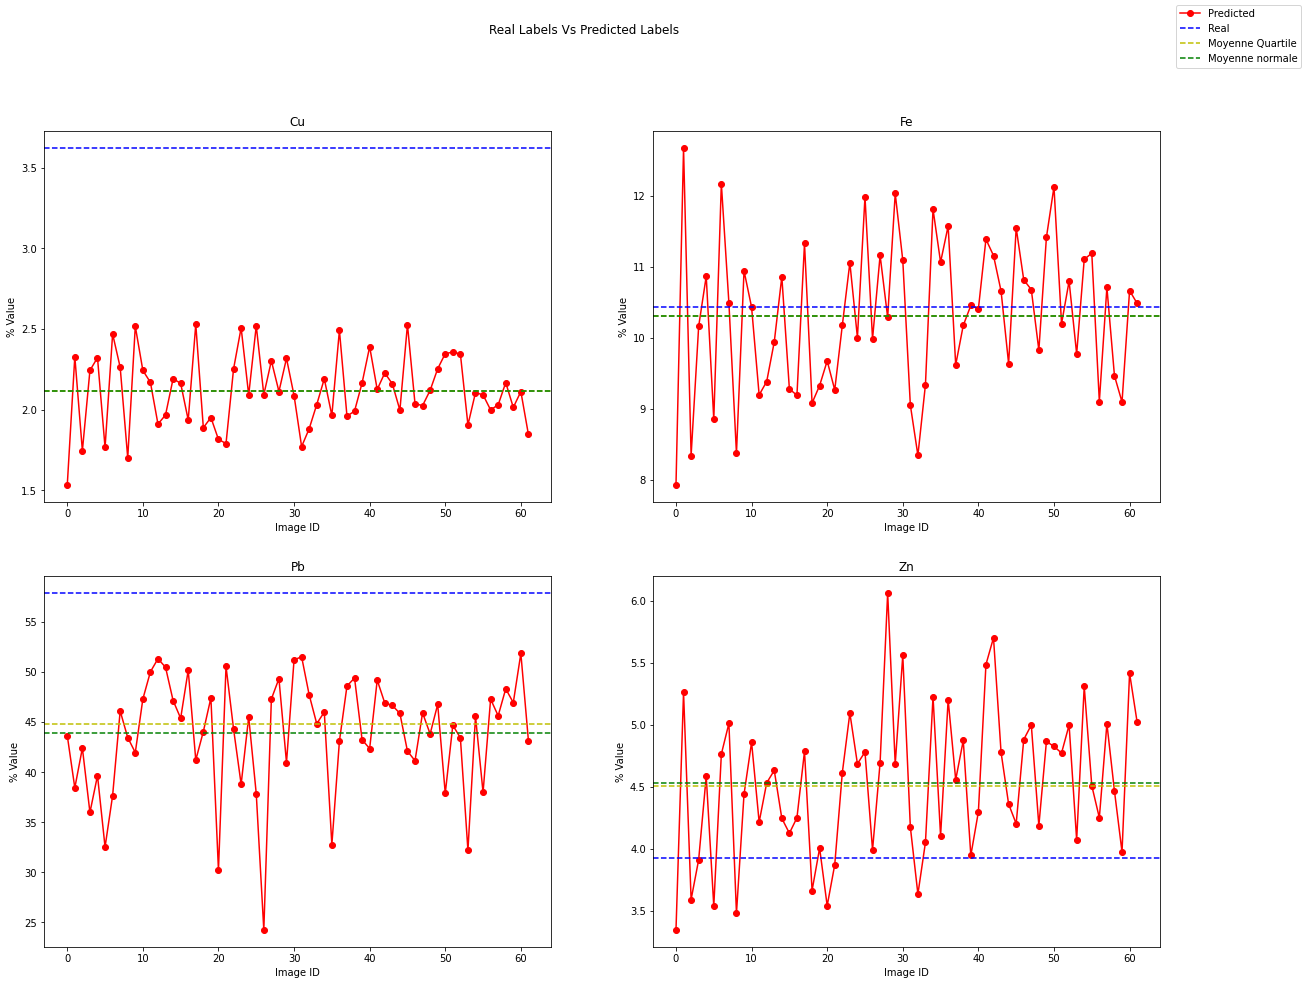

In [50]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", mrf)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

XGBoost

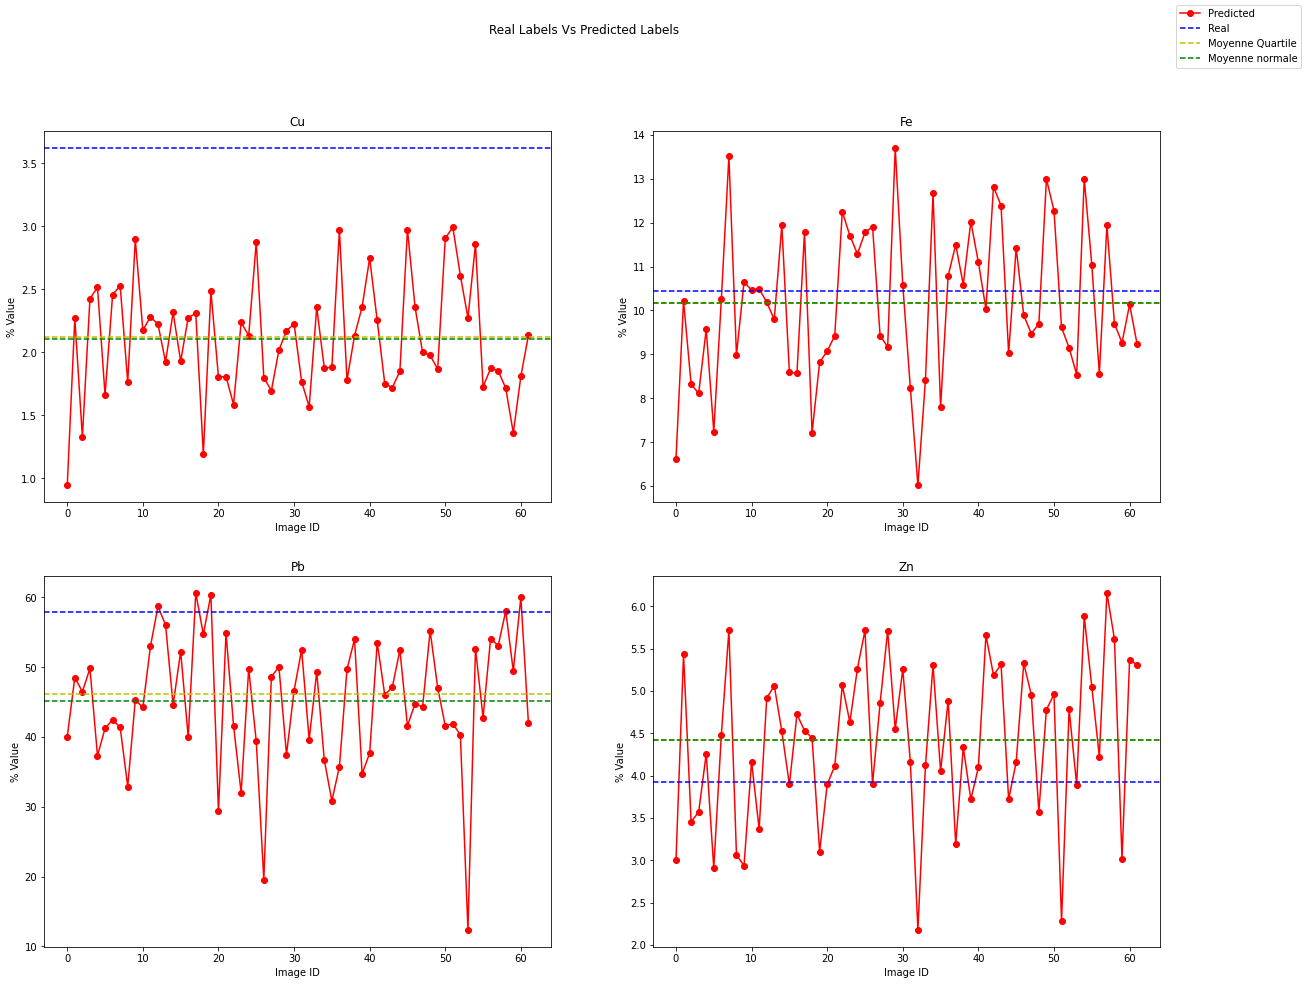

In [51]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", mxgb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Catboost

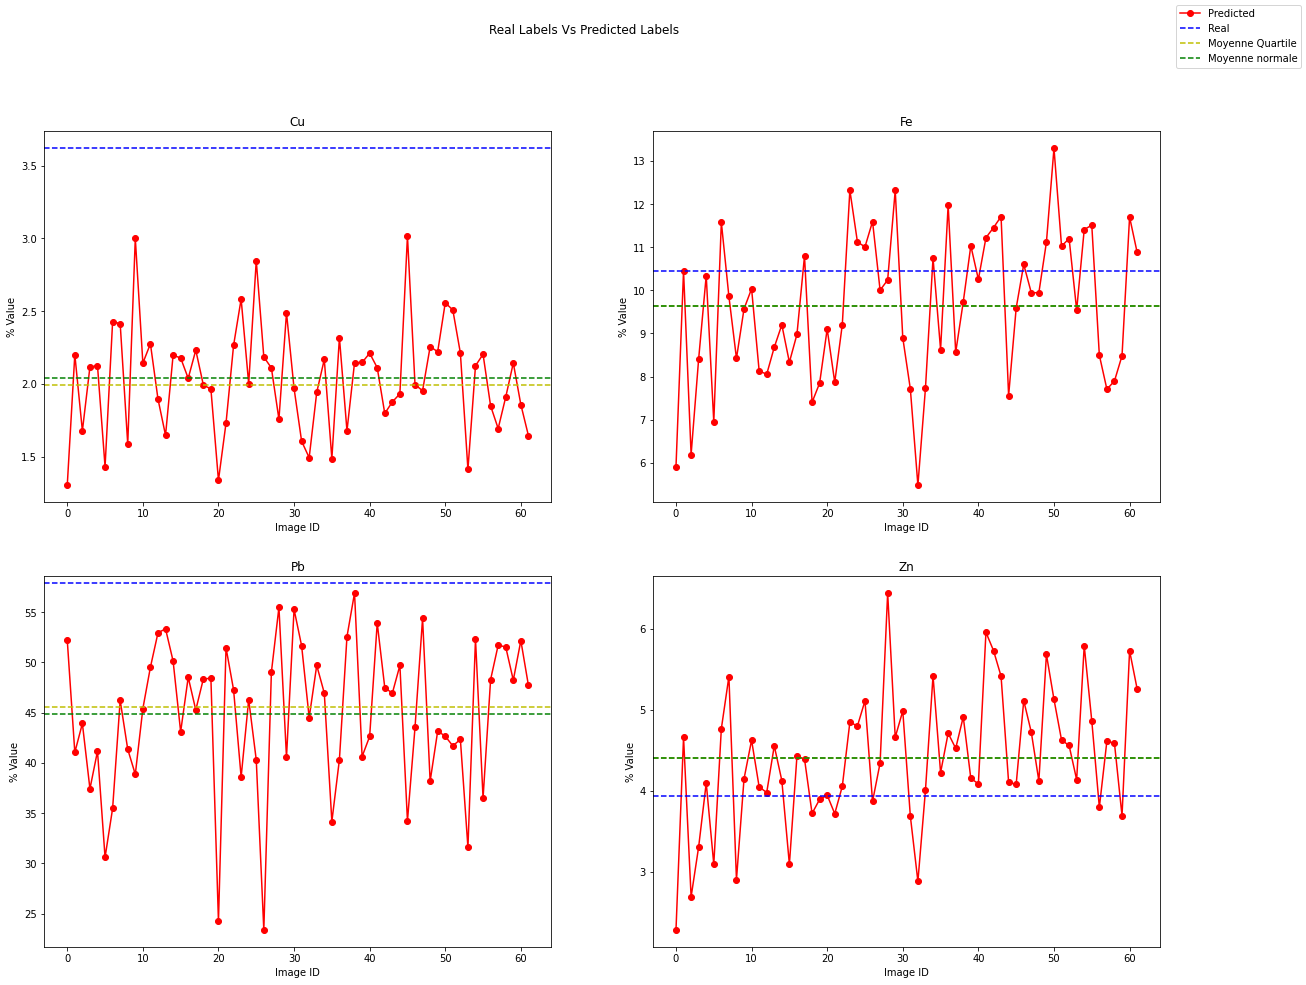

In [52]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", mcb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

# All test videos average

In [55]:
test_videos = ["rl4_pb12-4.mp4", "rl1_pb16-4.mp4", "rl3_pb23-4.mp4", "rl1_pb9-5.mp4", "rl4_pb30-6.mp4"]
models = [msvm, mrf, mxgb, mcb, mgb, mada, mdt, mknn]

In [56]:
final_results_df = pd.DataFrame(columns=["Model", "Cu", "Fe", "Pb", "Zn"])

In [57]:
for model in models:
    model_name = type(model.estimator).__name__
    avgs_cu, avgs_fe, avgs_pb, avgs_zn = [], [], [], []
    for test_vid in test_videos:
        TeunneurReel = TenneurReel(test_vid, "DataSource.xlsx")
        Teneur_predit = predict_video("../video_test/" + test_vid, model)
        Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
        avgs_cu.append(abs(TeunneurReel[0] - Moyenne[0]))
        avgs_fe.append(abs(TeunneurReel[1] - Moyenne[1]))
        avgs_pb.append(abs(TeunneurReel[2] - Moyenne[2]))
        avgs_zn.append(abs(TeunneurReel[3] - Moyenne[3]))
        print(model_name + " " + test_vid + " done")
    avgs_cu = np.mean(avgs_cu)
    avgs_fe = np.mean(avgs_fe)
    avgs_pb = np.mean(avgs_pb)
    avgs_zn = np.mean(avgs_zn)
    final_results_df = pd.concat([final_results_df, pd.DataFrame({"Model": model_name, "Cu": avgs_cu, "Fe": avgs_fe, "Pb": avgs_pb, "Zn": avgs_zn}, index=[0])], ignore_index=True)

SVR rl4_pb12-4.mp4 done
SVR rl1_pb16-4.mp4 done
SVR rl3_pb23-4.mp4 done
SVR rl1_pb9-5.mp4 done
SVR rl4_pb30-6.mp4 done
RandomForestRegressor rl4_pb12-4.mp4 done
RandomForestRegressor rl1_pb16-4.mp4 done
RandomForestRegressor rl3_pb23-4.mp4 done
RandomForestRegressor rl1_pb9-5.mp4 done
RandomForestRegressor rl4_pb30-6.mp4 done
XGBRegressor rl4_pb12-4.mp4 done
XGBRegressor rl1_pb16-4.mp4 done
XGBRegressor rl3_pb23-4.mp4 done
XGBRegressor rl1_pb9-5.mp4 done
XGBRegressor rl4_pb30-6.mp4 done
CatBoostRegressor rl4_pb12-4.mp4 done
CatBoostRegressor rl1_pb16-4.mp4 done
CatBoostRegressor rl3_pb23-4.mp4 done
CatBoostRegressor rl1_pb9-5.mp4 done
CatBoostRegressor rl4_pb30-6.mp4 done
GradientBoostingRegressor rl4_pb12-4.mp4 done
GradientBoostingRegressor rl1_pb16-4.mp4 done
GradientBoostingRegressor rl3_pb23-4.mp4 done
GradientBoostingRegressor rl1_pb9-5.mp4 done
GradientBoostingRegressor rl4_pb30-6.mp4 done
AdaBoostRegressor rl4_pb12-4.mp4 done
AdaBoostRegressor rl1_pb16-4.mp4 done
AdaBoostRegres

In [58]:
final_results_df

,Model,Cu,Fe,Pb,Zn
0,SVR,0.788315,3.883035,12.880749,1.177205
1,RandomForestRegressor,0.693605,3.137268,8.380914,1.250317
2,XGBRegressor,0.727500,2.947093,7.633041,1.209546
3,CatBoostRegressor,0.726113,2.882670,8.050951,1.190892
4,GradientBoostingRegressor,0.692462,2.988582,8.174781,1.163140
5,AdaBoostRegressor,0.806758,3.763127,9.397196,1.295960
6,DecisionTreeRegressor,0.793053,3.438324,10.125517,1.152084
7,KNeighborsRegressor,0.812097,3.082230,6.638384,1.202826


In [61]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [132]:
nn = Sequential()
nn.add(Dense(400, activation='relu', input_shape=(fft_features.shape[1],)))
nn.add(Dropout(0.2))
nn.add(Dense(200, activation='relu'))
nn.add(Dropout(0.2))
nn.add(Dense(50, activation='relu'))
nn.add(Dense(4, activation='linear'))

opt = Adam(learning_rate=0.0001)
nn.compile(optimizer=opt, metrics=['mae'], loss='mse')

In [133]:
hist = nn.fit(fft_features, labels, epochs=200, batch_size=16, verbose=1)

Epoch 1/200
98/98 [==============================] - 2s 5ms/step - loss: 122.4733 - mae: 7.7821
Epoch 2/200
98/98 [==============================] - 0s 4ms/step - loss: 81.9604 - mae: 6.1224
Epoch 3/200
98/98 [==============================] - 0s 4ms/step - loss: 75.4593 - mae: 5.7172
Epoch 4/200
98/98 [==============================] - 0s 5ms/step - loss: 69.8139 - mae: 5.4520
Epoch 5/200
98/98 [==============================] - 0s 5ms/step - loss: 66.4568 - mae: 5.2519
Epoch 6/200
98/98 [==============================] - 0s 4ms/step - loss: 64.5641 - mae: 5.1158
Epoch 7/200
98/98 [==============================] - 0s 4ms/step - loss: 63.8280 - mae: 5.0838
Epoch 8/200
98/98 [==============================] - 0s 4ms/step - loss: 60.6334 - mae: 4.9191
Epoch 9/200
98/98 [==============================] - 0s 4ms/step - loss: 59.2719 - mae: 4.8038
Epoch 10/200
98/98 [==============================] - 0s 4ms/step - loss: 58.4497 - mae: 4.7641
Epoch 11/200
98/98 [============================

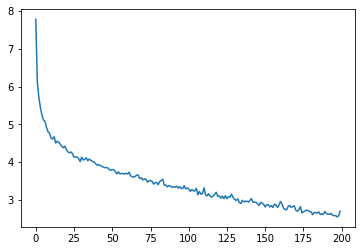

In [134]:
plt.plot(hist.history['mae'])
plt.show()

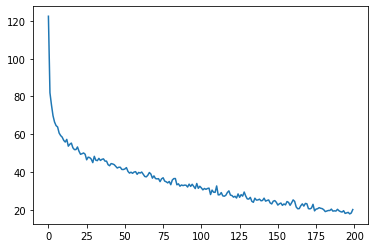

In [135]:
plt.plot(hist.history['loss'])
plt.show()

In [136]:
y_pred = nn.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.926304213649451
MSE 64.34164569283124
R2 Score -0.07338580190032973


In [137]:
model_name = "Neural Network"
avgs_cu, avgs_fe, avgs_pb, avgs_zn = [], [], [], []
for test_vid in test_videos:
    TeunneurReel = TenneurReel(test_vid, "DataSource.xlsx")
    Teneur_predit = predict_video("../video_test/" + test_vid, nn)
    Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
    avgs_cu.append(abs(TeunneurReel[0] - Moyenne[0]))
    avgs_fe.append(abs(TeunneurReel[1] - Moyenne[1]))
    avgs_pb.append(abs(TeunneurReel[2] - Moyenne[2]))
    avgs_zn.append(abs(TeunneurReel[3] - Moyenne[3]))
    print(model_name + " " + test_vid + " done")
avgs_cu = np.mean(avgs_cu)
avgs_fe = np.mean(avgs_fe)
avgs_pb = np.mean(avgs_pb)
avgs_zn = np.mean(avgs_zn)
t = pd.concat([final_results_df, pd.DataFrame({"Model": model_name, "Cu": avgs_cu, "Fe": avgs_fe, "Pb": avgs_pb, "Zn": avgs_zn}, index=[0])], ignore_index=True)

Neural Network rl4_pb12-4.mp4 done
Neural Network rl1_pb16-4.mp4 done
Neural Network rl3_pb23-4.mp4 done
Neural Network rl1_pb9-5.mp4 done
Neural Network rl4_pb30-6.mp4 done


In [138]:
t

,Model,Cu,Fe,Pb,Zn
0,SVR,0.788315,3.883035,12.880749,1.177205
1,RandomForestRegressor,0.693605,3.137268,8.380914,1.250317
2,XGBRegressor,0.727500,2.947093,7.633041,1.209546
3,CatBoostRegressor,0.726113,2.882670,8.050951,1.190892
4,GradientBoostingRegressor,0.692462,2.988582,8.174781,1.163140
5,AdaBoostRegressor,0.806758,3.763127,9.397196,1.295960
6,DecisionTreeRegressor,0.793053,3.438324,10.125517,1.152084
7,KNeighborsRegressor,0.812097,3.082230,6.638384,1.202826
8,Neural Network,0.824419,2.669737,9.046821,1.520403
